In [ ]:
!pip install tensorflow shap xgboost scikit-learn opencv-python-headless -q
print(" Tools installed.")

 Tools installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Soil_Analytics_Project'
MODEL_DIR = f'{PROJECT_DIR}/models'
REPORT_DIR = f'{PROJECT_DIR}/reports'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Images:", os.listdir(f'{PROJECT_DIR}/cleaned_images'))
print("CSVs:", [f for f in os.listdir(f'{PROJECT_DIR}/cleaned_data') if f.endswith('.csv')])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images: ['train', 'val', 'test', 'augmented']
CSVs: ['Crop_recommendation_cleaned.csv', 'Fertilizer_recommendation_cleaned.csv', 'Data Labels - Relative for Params_cleaned.csv', 'data_core_cleaned.csv', 'Data Labels - Relative for Soil Fertility_cleaned.csv', 'soil_cleaned.csv', 'data_cleaned.csv', 'Crop_recommendation_encoded_cleaned.csv', 'testdata2wls_cleaned.csv', 'testdata1fls_cleaned.csv', 'data_core_encoded_cleaned.csv']


In [ ]:
import tensorflow as tf
print(" GPU found:", tf.config.list_physical_devices('GPU'))

 GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_dir = f'{PROJECT_DIR}/cleaned_images/train'
val_dir   = f'{PROJECT_DIR}/cleaned_images/val'
test_dir  = f'{PROJECT_DIR}/cleaned_images/test'

class_names = sorted(os.listdir(train_dir))
print("  Soil type classes:", class_names)

for split, path in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    print(f"\n{split.upper()}:")
    for c in class_names:
        n = len(os.listdir(os.path.join(path, c)))
        print(f"  {c}: {n} photos")

  Soil type classes: ['Black_Soil', 'Cinder_Soil', 'Laterite_Soil', 'Peat_Soil', 'Yellow_Soil']

TRAIN:
  Black_Soil: 96 photos
  Cinder_Soil: 72 photos
  Laterite_Soil: 63 photos
  Peat_Soil: 69 photos
  Yellow_Soil: 66 photos

VAL:
  Black_Soil: 8 photos
  Cinder_Soil: 5 photos
  Laterite_Soil: 5 photos
  Peat_Soil: 5 photos
  Yellow_Soil: 7 photos

TEST:
  Black_Soil: 10 photos
  Cinder_Soil: 7 photos
  Laterite_Soil: 5 photos
  Peat_Soil: 6 photos
  Yellow_Soil: 5 photos


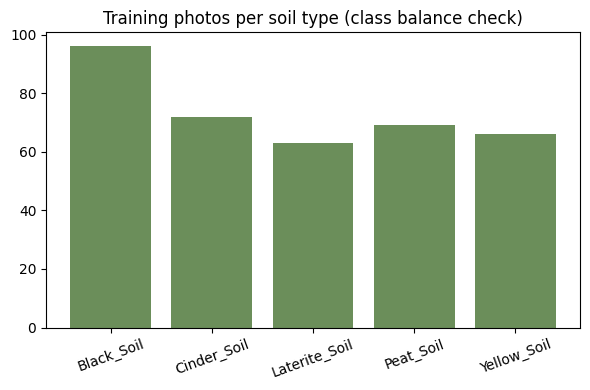

In [ ]:
import matplotlib.pyplot as plt

counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in class_names}
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color='#6b8e5a')
plt.title('Training photos per soil type (class balance check)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
import shutil

aug_dir = f'{PROJECT_DIR}/cleaned_images/augmented'
for cls in class_names:
    src = os.path.join(aug_dir, cls)
    dst = os.path.join(train_dir, cls)
    if os.path.isdir(src):
        for fname in os.listdir(src):
            shutil.copy(os.path.join(src, fname), os.path.join(dst, fname))

print("Train photos after merging augmented copies:")
for c in class_names:
    print(f"  {c}: {len(os.listdir(os.path.join(train_dir, c)))} photos")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)
print("Class order:", train_ds.class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Train photos after merging augmented copies:
  Black_Soil: 96 photos
  Cinder_Soil: 72 photos
  Laterite_Soil: 63 photos
  Peat_Soil: 69 photos
  Yellow_Soil: 66 photos
Found 366 files belonging to 5 classes.
Found 30 files belonging to 5 classes.
Found 33 files belonging to 5 classes.
Class order: ['Black_Soil', 'Cinder_Soil', 'Laterite_Soil', 'Peat_Soil', 'Yellow_Soil']


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers

NUM_CLASSES = len(class_names)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

preprocess_input = tf.keras.applications.resnet50.preprocess_input

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
conv_features = base_model(x, training=False)   # keep a direct handle to this exact tensor
x = layers.GlobalAveragePooling2D()(conv_features)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# A second model, built from the SAME graph, dedicated to Grad-CAM - no name lookups needed, ever
grad_cam_model = tf.keras.Model(inputs, [conv_features, outputs])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5)         │     10,245 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(" Model compiled with Adam optimizer, learning rate = 0.0001")

 Model compiled with Adam optimizer, learning rate = 0.0001


In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = []
for cls_idx, cls in enumerate(class_names):
    train_labels += [cls_idx] * len(os.listdir(os.path.join(train_dir, cls)))
class_weights_arr = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=train_labels)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights (helps the weaker classes like Laterite get more attention):", class_weight_dict)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(f'{MODEL_DIR}/best_cnn_model.keras', monitor='val_accuracy', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7),
]

EPOCHS = 60
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Class weights (helps the weaker classes like Laterite get more attention): {0: np.float64(0.7625), 1: np.float64(1.0166666666666666), 2: np.float64(1.161904761904762), 3: np.float64(1.0608695652173914), 4: np.float64(1.1090909090909091)}
Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 519ms/step - accuracy: 0.1885 - loss: 2.1916 - val_accuracy: 0.4000 - val_loss: 1.4721 - learning_rate: 1.0000e-04
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.2678 - loss: 1.8927 - val_accuracy: 0.5000 - val_loss: 1.3306 - learning_rate: 1.0000e-04
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.2978 - loss: 1.7677 - val_accuracy: 0.4667 - val_loss: 1.2377 - learning_rate: 1.0000e-04
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.3333 - loss: 1.6884 - val_accuracy: 0.6667 - val_loss: 1.1305 - learning_rate: 1.0000e-04
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.3743 - loss: 1.6509 - val_accuracy: 0.6333 - val_loss: 1.0472 - learning_

In [33]:
FINE_TUNE = True   # flipped ON this time

if FINE_TUNE:
    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=callbacks,
        class_weight=class_weight_dict   # was missing before — Laterite needs this help
    )
    print("Fine-tuning complete.")
else:
    print("Skipped fine-tuning.")

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 219ms/step - accuracy: 0.6776 - loss: 0.8912 - val_accuracy: 0.8333 - val_loss: 0.5882 - learning_rate: 1.0000e-05
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.7268 - loss: 0.7976 - val_accuracy: 0.8667 - val_loss: 0.5592 - learning_rate: 1.0000e-05
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.7432 - loss: 0.7191 - val_accuracy: 0.8667 - val_loss: 0.5355 - learning_rate: 1.0000e-05
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.7295 - loss: 0.6967 - val_accuracy: 0.8667 - val_loss: 0.5106 - learning_rate: 1.0000e-05
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.7678 - loss: 0.6724 - val_accuracy: 0.8667 - val_loss: 0.4929 - learning_rate: 5.0000e-06
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.7678 - loss: 0.6404 - val_accuracy: 0.8667 - val_loss: 0.4728 - learning_rate: 5.0000e-06
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy:

In [ ]:
FINE_TUNE = False

if FINE_TUNE:
    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history_fine = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)
    print(" Fine-tuning complete.")
else:
    print("Skipped fine-tuning — only turn this on if the chart above shows overfitting/underfitting.")

In [35]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.3f}   (out of every 100 guesses, how many were exactly right)")
print(f"Precision: {precision:.3f}   (when it SAYS 'Black Soil', how often is it actually right)")
print(f"Recall:    {recall:.3f}   (out of all the REAL Black Soil photos, how many did it catch)")
print(f"F1-score:  {f1:.3f}   (a fair average balancing precision & recall)")

print("\nFull per-class report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Accuracy:  0.818   (out of every 100 guesses, how many were exactly right)
Precision: 0.807   (when it SAYS 'Black Soil', how often is it actually right)
Recall:    0.818   (out of all the REAL Black Soil photos, how many did it catch)
F1-score:  0.804   (a fair average balancing precision & recall)

Full per-class report:
               precision    recall  f1-score   support

   Black_Soil       0.91      1.00      0.95        10
  Cinder_Soil       0.75      0.86      0.80         7
Laterite_Soil       0.67      0.40      0.50         5
    Peat_Soil       0.80      0.67      0.73         6
  Yellow_Soil       0.83      1.00      0.91         5

     accuracy                           0.82        33
    macro avg       0.79      0.78      0.78        33
 weighted avg       0.81      0.82      0.80        33



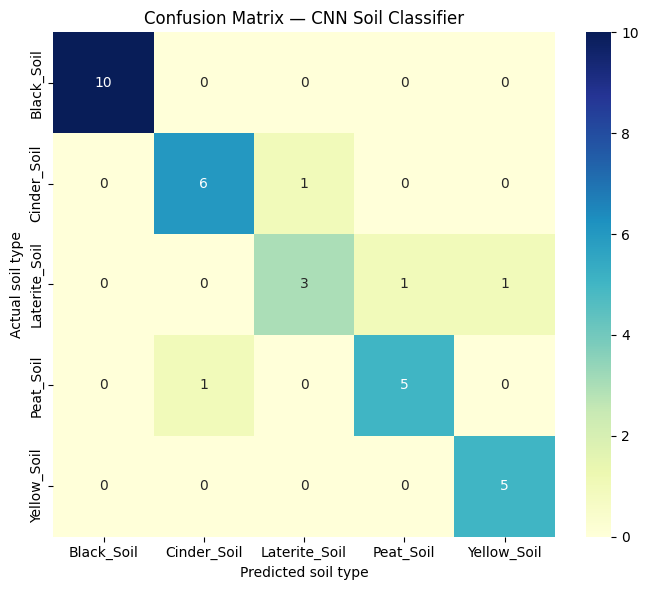

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted soil type')
plt.ylabel('Actual soil type')
plt.title('Confusion Matrix — CNN Soil Classifier')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/cnn_confusion_matrix.png', dpi=120)
plt.show()


In [ ]:
import pandas as pd

# Turn the confusion picture into a clear number table
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("Rows = the REAL soil type. Columns = what the robot GUESSED.")
print(cm_df)

print("\n For each soil type, what does the robot confuse it with most?")
for soil in class_names:
    row = cm_df.loc[soil].drop(soil)
    if row.sum() > 0:
        print(f"  {soil} → most often confused with: {row.idxmax()} ({row.max()} times)")
    else:
        print(f"  {soil} → no mix-ups! ")

Rows = the REAL soil type. Columns = what the robot GUESSED.
               Black_Soil  Cinder_Soil  Laterite_Soil  Peat_Soil  Yellow_Soil
Black_Soil             10            0              0          0            0
Cinder_Soil             0            6              1          0            0
Laterite_Soil           0            0              3          1            1
Peat_Soil               0            1              0          5            0
Yellow_Soil             0            0              0          0            5

 For each soil type, what does the robot confuse it with most?
  Black_Soil → no mix-ups! 
  Cinder_Soil → most often confused with: Laterite_Soil (1 times)
  Laterite_Soil → most often confused with: Peat_Soil (1 times)
  Peat_Soil → most often confused with: Cinder_Soil (1 times)
  Yellow_Soil → no mix-ups! 


Total wrong guesses: 6 out of 33


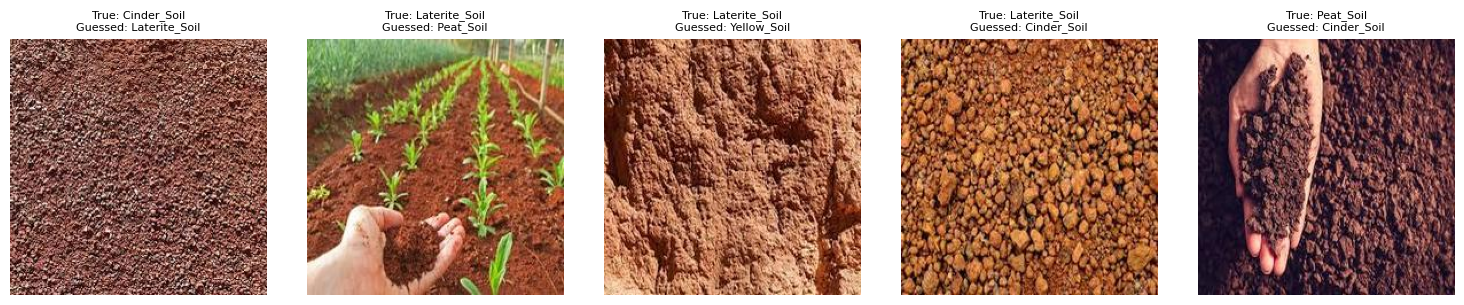

In [38]:
wrong_indices = np.where(y_true != y_pred)[0]
print(f"Total wrong guesses: {len(wrong_indices)} out of {len(y_true)}")

test_paths = []
for c in class_names:
    folder = os.path.join(test_dir, c)
    for f in sorted(os.listdir(folder)):
        test_paths.append(os.path.join(folder, f))

if len(wrong_indices) > 0:
    fig, axes = plt.subplots(1, min(5, len(wrong_indices)), figsize=(15, 3))
    if len(wrong_indices) == 1:
        axes = [axes]
    for i, idx in enumerate(wrong_indices[:5]):
        img = tf.keras.utils.load_img(test_paths[idx])
        axes[i].imshow(img)
        axes[i].set_title(f"True: {class_names[y_true[idx]]}\nGuessed: {class_names[y_pred[idx]]}", fontsize=8)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(" Zero mistakes on the test set!")

In [ ]:
import pandas as pd

params_path = [f for f in os.listdir(f'{PROJECT_DIR}/cleaned_data') if 'Relative for Params' in f][0]
fert_path = [f for f in os.listdir(f'{PROJECT_DIR}/cleaned_data') if 'Relative for Soil Fertility' in f][0]

params_df = pd.read_csv(f'{PROJECT_DIR}/cleaned_data/{params_path}')
fert_df = pd.read_csv(f'{PROJECT_DIR}/cleaned_data/{fert_path}')

params_df = params_df.rename(columns={'pointid': 'point_id'})
merged_df = params_df.merge(fert_df, on='point_id')

print(f"Joined dataset: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns")
merged_df.head()

Joined dataset: 18984 rows, 10 columns


,point_id,ph_cacl2,ph_h20,ec,oc,caco3,p,n,k,Rel_soil_fertility_category
0,47862690,1,1,0,0,0,0,0,0,0
1,47882704,1,1,0,0,0,0,0,0,0
2,47982688,1,1,0,1,0,0,1,0,0
3,48022702,2,2,1,0,0,0,0,0,1
4,48062708,3,2,0,0,0,0,0,0,1


In [40]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=merged_df)

https://docs.google.com/spreadsheets/d/1wb7zTj4dS6cU5lMzwscPisc1eCrCrNu5v3LSvuHT5Ho/edit#gid=0


In [ ]:
FEATURES = ['ph_cacl2', 'ph_h20', 'ec', 'oc', 'caco3', 'p', 'n', 'k']
TARGET = 'Rel_soil_fertility_category'

X = merged_df[FEATURES]
y = merged_df[TARGET]

print(" Input features:", FEATURES)
print(" Target classes:", sorted(y.unique()), " (0 = low fertility, 1 = medium, 2 = high — verify against your data dictionary)")
print("\nHow many of each target class we have:")
print(y.value_counts())

In [ ]:
correlations = merged_df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("How much each feature relates to the target (higher absolute value = more important):")
print(correlations)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training rows: {len(X_train)}  |  Testing rows: {len(X_test)}")

Training rows: 15187  |  Testing rows: 3797


In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(y.unique()),
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
print(" XGBoost model trained.")

 XGBoost model trained.


In [45]:
y_pred_xgb = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_xgb)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='weighted', zero_division=0)

print(f" Accuracy:  {acc:.3f}")
print(f" Precision: {prec:.3f}")
print(f" Recall:    {rec:.3f}")
print(f" F1-score:  {f1:.3f}")

print("\n Full per-class report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

 Accuracy:  1.000
 Precision: 1.000
 Recall:    1.000
 F1-score:  1.000

 Full per-class report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1334
           1       1.00      1.00      1.00      1385
           2       1.00      1.00      1.00      1078

    accuracy                           1.00      3797
   macro avg       1.00      1.00      1.00      3797
weighted avg       1.00      1.00      1.00      3797



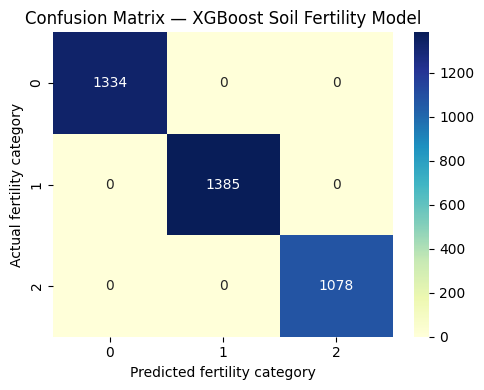

In [46]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted fertility category')
plt.ylabel('Actual fertility category')
plt.title('Confusion Matrix — XGBoost Soil Fertility Model')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/xgboost_confusion_matrix.png', dpi=120)
plt.show()

In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
}

search = GridSearchCV(
    XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), eval_metric='mlogloss', random_state=42),
    param_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)

search.fit(X_train, y_train)

print("Best settings found:", search.best_params_)
print(f"Best cross-validated F1-score: {search.best_score_:.3f}")

best_xgb_model = search.best_estimator_

Best settings found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best cross-validated F1-score: 1.000


In [ ]:
y_pred_best = best_xgb_model.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Final tuned model accuracy on test data: {acc_best:.3f}")

import joblib
joblib.dump(best_xgb_model, f'{MODEL_DIR}/xgboost_soil_fertility_model.pkl')
print(f" Best XGBoost model saved to {MODEL_DIR}/xgboost_soil_fertility_model.pkl")

In [ ]:
import cv2

def make_gradcam_heatmap(img_array, grad_cam_model):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_cam_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def show_gradcam(img_path, grad_cam_model, class_names):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array_batch = np.expand_dims(img_array, axis=0)

    heatmap, pred_idx = make_gradcam_heatmap(img_array_batch, grad_cam_model)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_array.astype('uint8'), 0.6, heatmap_color, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_array.astype('uint8'))
    axes[0].set_title('Original photo')
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f'Grad-CAM: predicted "{class_names[pred_idx]}"')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

for path in test_paths[:3]:
    show_gradcam(path, grad_cam_model, class_names)

In [ ]:
import shap

explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

print(" SHAP values calculated for every test row and every feature.")

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/shap_summary_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Red dots = high feature value, blue = low value.")

In [ ]:
sample_idx = 0
predicted_class = best_xgb_model.predict(X_test.iloc[[sample_idx]])[0]

print(f"Explaining prediction for test row #{sample_idx}:")
print(X_test.iloc[sample_idx])
print(f"Actual category: {y_test.iloc[sample_idx]}  |  Predicted: {predicted_class}")

if isinstance(shap_values, list):
    importances = shap_values[predicted_class][sample_idx]
elif shap_values.ndim == 3:
    importances = shap_values[sample_idx, :, predicted_class]
else:
    importances = shap_values[sample_idx]

importance_df = pd.DataFrame({'feature': FEATURES, 'shap_value': importances}).sort_values('shap_value', key=abs, ascending=False)
print("\nWhich features pushed this specific prediction the most:")
print(importance_df)

In [53]:
def get_cnn_prediction(img_path, model, class_names):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = np.expand_dims(tf.keras.utils.img_to_array(img), axis=0)
    preds = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(preds)
    return class_names[pred_idx], float(preds[pred_idx])

def get_structured_prediction(soil_features_dict, xgb_model, feature_order):
    row = pd.DataFrame([soil_features_dict])[feature_order]
    pred = xgb_model.predict(row)[0]
    proba = xgb_model.predict_proba(row)[0]
    confidence = float(np.max(proba))
    return int(pred), confidence

def hybrid_soil_assessment(img_path, soil_features_dict, cnn_model, xgb_model, class_names, feature_order):
    """Combines both brains into one final report."""
    soil_type, img_confidence = get_cnn_prediction(img_path, cnn_model, class_names)
    fertility_category, struct_confidence = get_structured_prediction(soil_features_dict, xgb_model, feature_order)

    fertility_labels = {0: 'Low fertility', 1: 'Medium fertility', 2: 'High fertility'}
    overall_confidence = (img_confidence + struct_confidence) / 2
    fertility_score_map = {0: 30, 1: 65, 2: 90}
    soil_health_score = fertility_score_map.get(fertility_category, 50) * (0.5 + 0.5 * overall_confidence)

    return {
        'predicted_soil_type': soil_type,
        'image_model_confidence': round(img_confidence, 3),
        'predicted_fertility': fertility_labels.get(fertility_category, 'Unknown'),
        'structured_model_confidence': round(struct_confidence, 3),
        'overall_confidence': round(overall_confidence, 3),
        'soil_health_score': round(soil_health_score, 1),
    }

example_features = X_test.iloc[0].to_dict()
example_image = test_paths[0]

result = hybrid_soil_assessment(example_image, example_features, model, best_xgb_model, class_names, FEATURES)
print("FINAL HYBRID SOIL HEALTH REPORT:")
for k, v in result.items():
    print(f"   {k}: {v}")

FINAL HYBRID SOIL HEALTH REPORT:
   predicted_soil_type: Black_Soil
   image_model_confidence: 0.743
   predicted_fertility: High fertility
   structured_model_confidence: 0.994
   overall_confidence: 0.868
   soil_health_score: 84.1
